# 05 | Building a Tiny GPT
## Sprint 5 — Day 3

**Previous notebook:** `04` — a complete, working Transformer block.
Now we stack them into a real model.

---

GPT is a *decoder-only* Transformer. The key difference from an encoder
is **causal masking**: when predicting token `t`, the model must not be
allowed to see tokens at positions `t+1, t+2, ...`. We enforce this with
an upper-triangular mask applied inside the attention step.

In this notebook we stack `N` Transformer blocks, add a language model head
(a linear projection from `d_model` to `vocab_size`), and confirm the full
forward pass works end to end.

---

**By the end of this notebook you will have:**
- Implemented causal (masked) self-attention
- Stacked `N` Transformer blocks into a `GPT` module
- Added the language model head that maps hidden states to vocabulary logits
- Run a full forward pass and confirmed output shape: `(batch, seq_len, vocab_size)`

---

*Next notebook: `06_training_loop_and_generation.ipynb`*

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

d_model     = 64
num_heads   = 8
d_ff        = 256
num_blocks  = 4
max_seq_len = 64
vocab_size  = 256
batch_size  = 2
seq_len     = 16

assert d_model % num_heads == 0

def positional_encoding(max_seq_len, d_model):
    PE = torch.zeros(max_seq_len, d_model)
    position = torch.arange(0, max_seq_len).unsqueeze(1).float()
    div_term = torch.pow(10000.0, torch.arange(0, d_model, 2).float() / d_model)
    PE[:, 0::2] = torch.sin(position / div_term)
    PE[:, 1::2] = torch.cos(position / div_term)
    return PE

class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(max_seq_len, d_model)
    def forward(self, x):
        return self.embedding(x) + self.pe[:x.shape[1], :]

class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
        self.eps   = eps
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std  = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))

print("Setup complete.")
print(f"d_model={d_model} | heads={num_heads} | blocks={num_blocks} | vocab={vocab_size}")

Setup complete.
d_model=64 | heads=8 | blocks=4 | vocab=256


**CASUAL ATTENTON**

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def make_causal_mask(self, T):
        return torch.tril(torch.ones(T, T))

    def forward(self, x):
        B, T, _ = x.shape
        Q = self.W_Q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        mask = self.make_causal_mask(T)
        attn_out, weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_O(attn_out), weights

**UPDATED TRANSFORMER BLOCK**

In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff        = FeedForward(d_model, d_ff)
        self.norm1     = LayerNorm(d_model)
        self.norm2     = LayerNorm(d_model)

    def forward(self, x):
        attn_out, weights = self.attention(x)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x, weights

**GPT MODEL**

In [4]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_blocks, max_seq_len):
        super().__init__()
        self.embedding = InputEmbedding(vocab_size, d_model, max_seq_len)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff)
            for _ in range(num_blocks)
        ])
        self.norm      = LayerNorm(d_model)
        self.lm_head   = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x):
        x = self.embedding(x)
        all_weights = []
        for block in self.blocks:
            x, weights = block(x)
            all_weights.append(weights)
        x = self.norm(x)
        logits = self.lm_head(x)
        return logits, all_weights

**SANITY CHECK**

In [5]:
model = GPT(vocab_size, d_model, num_heads, d_ff, num_blocks, max_seq_len)

dummy_tokens = torch.randint(0, vocab_size, (batch_size, seq_len))
logits, all_weights = model(dummy_tokens)

total_params = sum(p.numel() for p in model.parameters())

print(f"Input shape:        {dummy_tokens.shape}")
print(f"Logits shape:       {logits.shape}")
print(f"Attention layers:   {len(all_weights)}")
print(f"Total parameters:   {total_params:,}")

Input shape:        torch.Size([2, 16])
Logits shape:       torch.Size([2, 16, 256])
Attention layers:   4
Total parameters:   231,808


**VISUALIZING CASUAL MASK**

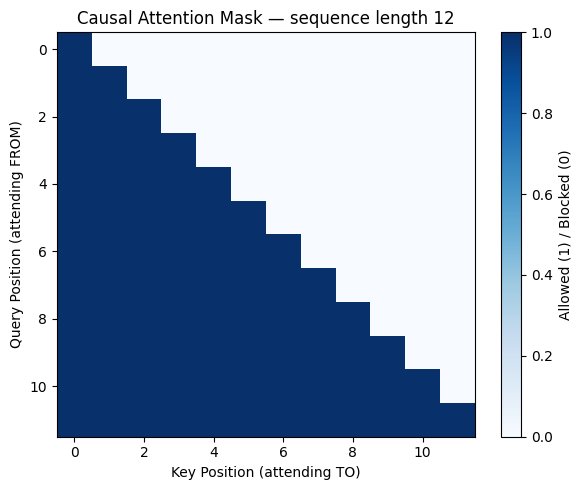

In [6]:
T = 12
mask = torch.tril(torch.ones(T, T))

plt.figure(figsize=(6, 5))
plt.imshow(mask.numpy(), cmap='Blues', aspect='auto')
plt.colorbar(label='Allowed (1) / Blocked (0)')
plt.xlabel('Key Position (attending TO)')
plt.ylabel('Query Position (attending FROM)')
plt.title(f'Causal Attention Mask — sequence length {T}')
plt.tight_layout()
plt.show()

**VERIFY CASUALITY**

In [7]:
with torch.no_grad():
    test_input = torch.randint(0, vocab_size, (1, seq_len))
    logits_original, _ = model(test_input)

    test_input_modified = test_input.clone()
    test_input_modified[0, -1] = (test_input[0, -1] + 1) % vocab_size
    logits_modified, _ = model(test_input_modified)

changed_positions = (logits_original[0] != logits_modified[0]).any(dim=-1)
print("Positions affected by changing the last token:")
print(changed_positions)

Positions affected by changing the last token:
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True])


# Sprint 5 Summary — Building a Tiny GPT

---

## What This Sprint Built

A complete GPT-style language model by stacking $N$ Transformer blocks, adding causal
masking to enforce autoregressive generation, and attaching a language model head that
projects hidden states into a probability distribution over the vocabulary.

---

## The Key Shift: Encoder → Decoder

Everything in Sprints 1–4 was an **encoder** — it reads a sequence and produces
enriched representations. A language model is a **decoder** — it generates sequences
by predicting one token at a time, never looking ahead.

The single change that makes this possible: **causal masking**.

---

## Concept 1 — Causal Masking

During training, the model sees the full sequence at once (for efficiency).
But it must not be allowed to look at future tokens when predicting a token —
otherwise it just copies the answer and learns nothing.

The causal mask enforces this by zeroing out all future positions in the attention
score matrix before softmax:

$$\text{Scores\_masked}_{ij} = \begin{cases} \text{Scores}_{ij} & \text{if } j \leq i \\ -\infty & \text{if } j > i \end{cases}$$

Since $e^{-\infty} = 0$, softmax assigns exactly zero weight to all future positions.
They contribute nothing to the output.

**The allowed attention pattern (sequence length 5):**

```
        Key positions →
        0    1    2    3    4
Q  0  [ ✓    ✗    ✗    ✗    ✗ ]   token 0 sees only itself
o  1  [ ✓    ✓    ✗    ✗    ✗ ]   token 1 sees 0 and 1
u  2  [ ✓    ✓    ✓    ✗    ✗ ]   token 2 sees 0, 1, 2
e  3  [ ✓    ✓    ✓    ✓    ✗ ]   token 3 sees 0, 1, 2, 3
r  4  [ ✓    ✓    ✓    ✓    ✓ ]   token 4 sees the full sequence
y  ↓
```

**Implementation:** `torch.tril(torch.ones(T, T))` creates the lower-triangular mask.
`masked_fill(mask == 0, float('-inf'))` applies it to the score matrix before softmax.

**Verified experimentally:** changing only the last token of a sequence left all
earlier positions' logits completely unchanged — confirming causality holds through
all $N$ blocks and all $h$ attention heads simultaneously.

---

## Concept 2 — Stacked Transformer Blocks

$N$ identical `TransformerBlock` instances are stacked in sequence.
Each block's output becomes the next block's input.
Because every block is shape-preserving — $(B, T, d_{model})$ in, $(B, T, d_{model})$ out —
stacking is architecturally trivial.

What depth buys beyond capacity:

| Block depth | What tends to emerge (trained models) |
|---|---|
| Early blocks | Surface patterns — syntax, token co-occurrence, proximity |
| Middle blocks | Semantic relationships — entity types, verb-argument structure |
| Later blocks | High-level reasoning — coreference, discourse, factual recall |

This hierarchy is not programmed — it emerges from the next-token prediction objective.

**`nn.ModuleList` is mandatory** for holding the blocks. A plain Python list is invisible
to PyTorch's parameter tracking — the optimiser would never update the blocks' weights.
`nn.ModuleList` registers every block as a proper submodule with tracked parameters.

---

## Concept 3 — The Language Model Head

After all $N$ blocks, a single linear projection maps each token's hidden state
from $d_{model}$ dimensions to $V$ vocabulary dimensions:

$$\text{logits} = x W_{lm} \qquad W_{lm} \in \mathbb{R}^{d_{model} \times V}$$

$$\text{logits} \in \mathbb{R}^{B \times T \times V}$$

Position $t$ in the logits gives 256 raw scores — one per vocabulary token.
This is the model's answer to: *"given everything I've seen up to position $t$,
what should come next?"*

| Usage | What happens to logits |
|---|---|
| Training | Fed directly into cross-entropy loss (softmax handled internally) |
| Generation | Softmax applied → probability distribution → sample next token |

---

## The Full Forward Pass

```
Input:   token indices        (B, T)
              ↓
InputEmbedding                (B, T, d_model)   meaning + position
              ↓
TransformerBlock 1            (B, T, d_model)   causal attn + FFN + Add&Norm
              ↓
TransformerBlock 2            (B, T, d_model)
              ↓
           ...
              ↓
TransformerBlock N            (B, T, d_model)
              ↓
Final LayerNorm               (B, T, d_model)   stabilise before projection
              ↓
LM Head: Linear(d_model, V)   (B, T, vocab_size) one score per vocab entry
              ↓
Output:  logits               (B, T, vocab_size)
```

The final LayerNorm before the LM head (GPT-2 convention) ensures hidden states
have stable scale regardless of how many residual additions accumulated across $N$ blocks.

---

## What The Causal Mask Heatmap Shows

The lower-triangular blue staircase pattern confirms:

- **Blue cells** = allowed attention (lower triangle + diagonal)
- **White cells** = blocked future positions (upper triangle = $-\infty$ before softmax)
- **Staircase grows by one step per row** = each token unlocks one more position
- **Diagonal always included** = every token always attends to itself

---

## Model Architecture Summary

| Component | Implementation | Parameters |
|---|---|---|
| Token + Position Embedding | `InputEmbedding` | $V \times d_{model}$ |
| Causal Attention (per block) | `MultiHeadAttention` + mask | $4 \times d_{model}^2$ |
| Feed-Forward (per block) | `FeedForward` | $2 \times d_{model} \times d_{ff}$ |
| Layer Norms (per block) | `LayerNorm` ×2 | $4 \times d_{model}$ |
| Final Layer Norm | `LayerNorm` | $2 \times d_{model}$ |
| LM Head | `nn.Linear` | $d_{model} \times V$ |

---

## Key Takeaways

- GPT is an encoder Transformer with two additions: causal masking and an LM head
- Causal masking sets future attention scores to $-\infty$, producing zero softmax weight
- Stacked blocks learn hierarchical representations — from surface syntax to high-level reasoning
- `nn.ModuleList` is required for PyTorch to register and optimise block parameters
- The LM head projects $(B, T, d_{model})$ to $(B, T, V)$ — logits for next-token prediction
- A final LayerNorm before the LM head stabilises the projection regardless of block depth
- Causality was verified experimentally: modifying the last token left all earlier positions unchanged

---

*Next: Sprint 6 — Training Loop & Text Generation.*
*We download a tiny text corpus, implement cross-entropy loss, write a complete*
*PyTorch training loop from scratch, train the model, and generate text.*
*The attention patterns you visualised as random noise will become structured and meaningful.*